## ESA CHANGE - Experiments with data and Random Forest 


In [7]:
# Setup and constants

# Import external packages
import numpy as np
import xarray as xr
from   netCDF4 import Dataset
import matplotlib.pyplot as plt
import pandas as pd
import math
import glob
import seaborn as sns
import sys
import os
from   tqdm.auto import tqdm
from   dask.diagnostics import ProgressBar
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from   pyproj import Transformer

# Import PML packages
# sys.path.append("/users/rsg/anla/code/satellite/match-maker/")
# from match_maker import extract

# Constants
KELVIN_TO_CELSIUS = -273.15

plots_root = '/data/datasets/Projects/CHANGE/data/outputs/plots'

# Initialisation
os.makedirs(plots_root, exist_ok=True)

In [2]:
# Open environmental multi-file datasets

env_file_patt = '/data/datasets/sst/esa-cci-sst/v3.0.1/global/1d/202?/??/??/*SST*.nc'

# Estimate number of files included
env_file_list = glob.glob(env_file_patt)
print (f'Env dataset contains {len(env_file_list)} files')

print ('Opening multi-file env data, this may take several minutes...')
with ProgressBar():
    env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords')
print ('Done')

# match_maker.extract.gridded.nearest(ds, points, k=1, return_distance=False, units='km')

# Tips for using Xarray for matchups:
# https://gis.stackexchange.com/questions/225100/extract-time-series-values-from-a-3d-lon-lat-time-netcdf-file-using-python


print(f'Variables: {list(env_ds.keys())}')
da = env_ds['analysed_sst'] + KELVIN_TO_CELSIUS
da

# Do we have to invert the array? 

Env dataset contains 2071 files
Opening multi-file env data, this may take several minutes...


/tmp/ipykernel_3373469/1509016097.py:11: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  env_ds = xr.open_mfdataset(env_file_patt, combine='by_coords')


Done
Variables: ['time_bnds', 'lat_bnds', 'lon_bnds', 'analysed_sst', 'analysed_sst_uncertainty', 'sea_ice_fraction', 'mask']


<xarray.DataArray 'analysed_sst' (time: 2071, lat: 3600, lon: 7200)> Size: 215GB
dask.array<add, shape=(2071, 3600, 7200), dtype=float32, chunksize=(1, 900, 1800), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 17kB 2020-01-01T12:00:00 ... 2025-09-01T12...
  * lat      (lat) float32 14kB -89.97 -89.93 -89.88 ... 89.88 89.93 89.97
  * lon      (lon) float32 29kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

In [3]:
# Load observed locations from CSV file - Surfers Against Sewage data on gastro cases
obs_data_root = '/data/datasets/Projects/CHANGE/data'
obs_data_name = os.path.join(obs_data_root, 'Surfers_Against_Sewage', 'sas_gastro_all_cases_23feb2026.csv')

obs_df = pd.read_csv(obs_data_name)
# Looks like 'n/a' are correctly turned into 'NaN' for missing data.

# Rename columns
obs_df.rename(columns={'Long':'lon', 'Lat':'lat'}, inplace=True)

# Correct data types, sometimes floats are read as strings due to n/a values
obs_df['lon'] = np.float32(obs_df['lon'])
obs_df['lat'] = np.float32(obs_df['lat'])

# Remove invalid rows, with missing lat/lon
obs_df = obs_df.dropna(subset=['lon', 'lat'])

# Add time variable, at midday for dates
obs_df['date_time'] = pd.to_datetime(obs_df['dateenteredwater'], dayfirst=True) + pd.Timedelta(hours=12)
obs_df

,Location,lat,lon,Water Company,Classification,dateenteredwater,Gatro,ENT,VIRAL,RESPIRATORY,ear_infection,skin_infection,other,drvisited,drattributedsicknesstowater,daysoffwork,date_time
0,Lowestoft South,52.464924,1.746256,Anglian Water,Good,19/05/2023,1,0,0,0,0,0,0,0.0,NaN,0.0,2023-05-19 12:00:00
1,Lowestoft South,52.464924,1.746256,Anglian Water,Good,29/08/2023,1,0,0,0,0,0,0,1.0,1.0,1.0,2023-08-29 12:00:00
2,Lowestoft South,52.464924,1.746256,Anglian Water,Good,11/12/2023,1,0,0,0,0,0,0,1.0,1.0,0.0,2023-12-11 12:00:00
3,Lowestoft South,52.464924,1.746256,Anglian Water,Good,11/02/2024,1,0,0,0,0,0,0,0.0,NaN,0.0,2024-02-11 12:00:00
4,Lowestoft South,52.464924,1.746256,Anglian Water,Good,18/08/2024,1,0,0,0,0,0,0,0.0,NaN,6.0,2024-08-18 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4822,Sennen,50.075581,-5.702987,South West Water,Excellent,02/08/2023,1,0,0,0,0,0,0,0.0,NaN,0.0,2023-08-02 12:00:00
4823,Sennen,50.075581,-5.702987,South West Water,Excellent,11/11/2023,1,0,0,0,0,0,0,0.0,NaN,1.0,2023-11-11 12:00:00
4824,Sennen,50.075581,-5.702987,South West Water,Excellent,14/08/2024,1,1,0,0,0,0,0,0.0,NaN,0.0,2024-08-14 12:00:00
4825,Sennen,50.075581,-5.702987,South West Water,Excellent,12/08/2023,1,0,0,0,0,0,0,1.0,1.0,14.0,2023-08-12 12:00:00


In [21]:
# Try a match-up with SST data

# Build coordinate arrays aligned to the DataFrame index
times = xr.DataArray(pd.DatetimeIndex(obs_df['date_time']), dims="points")
lats  = xr.DataArray(obs_df['lat'].values, dims="points")
lons  = xr.DataArray(obs_df['lon'].values, dims="points")

# Vectorised extraction
# NB produces a lot of 271.35 (=-2.0 'C?), perhaps many are too far inland (700 missing).
# 271.35 is temperature of Arctic water, I guess at (0,0) if lat/lon are NaN. -54.53K is missing.
print('Extracting matchups from dataset...')
method = 'nearest'
values = da.sel(
    time=times,
    lat=lats,
    lon=lons,
    method=method,
)

# Select then interpolate doesn't work for me (3441 missing?)
# values = (
#     da.sel(time=times, method=method)
#     .interp(lat=lats, lon=lons)
# )

obs_df['sst'] = values
print(f'Missing values: {obs_df['sst'].isnull().sum().sum() / len(obs_df):.1%}')

# Just show selected columns
print(f'Selected columns:')
print_df = pd.concat([obs_df.iloc[:, :6], obs_df.iloc[:, 16:]], axis='columns')
print_df

Extracting matchups from dataset...
Missing values: 12.1%
Selected columns:


,EUBWID,label,sampleTime,intestinalEnterococciQualifier,intestinalEnterococciCount,escherichiaColiQualifier,sst
0,ukc1101-06000,Seaton Carew North,2012-05-10T14:28:00,=,145.0,=,7.51001
1,ukc1101-06000,Seaton Carew North,2012-05-15T10:36:00,=,234.0,=,7.51001
2,ukc1101-06000,Seaton Carew North,2012-05-21T11:18:00,=,18.0,<,7.51001
3,ukc1101-06000,Seaton Carew North,2012-05-31T12:04:00,=,18.0,=,7.51001
4,ukc1101-06000,Seaton Carew North,2012-06-11T12:02:00,=,360.0,=,7.51001
...,...,...,...,...,...,...,...
99833,ukk4307-33900,Westward Ho!,2025-08-22T13:25:00,<,10.0,<,NaN
99834,ukk4307-33900,Westward Ho!,2025-08-27T11:05:00,<,10.0,<,NaN
99835,ukk4307-33900,Westward Ho!,2025-09-03T13:02:00,=,36.0,<,NaN
99836,ukk4307-33900,Westward Ho!,2025-09-07T10:00:00,<,10.0,=,NaN


In [24]:
%%script false --no-raise-error

# Uses slice for neighbourhood average, takes ~20 mins
lat_pad = lon_pad = 0.02  # half width of neighbourhood in degrees, so 0.02 gives ~5x5 km.
time_pad = pd.Timedelta(days=2)
results = []

# You can't use nearest in time if also using a slice in coordinates, so loop through each row of observations.
# Then use time and coords slice. But we should not average in time.
# tqdm makes a progress bar according to the rows of points completed.
for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using slice'):
    nhood = da.sel(
        time=slice(row['date_time'] - time_pad, row['date_time'] + time_pad),
        lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
        lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
    )
    results.append(float(nhood.mean()))

# Select time first, then slice coords. No, that will use the closest time whether or not region is missing.
# for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using xxx'):
#     nhood = (
#         da.sel(time=row['date_time'], method=method)
#         .sel(
#             lat=slice(row['lat'] - lat_pad, row['lat'] + lat_pad),
#             lon=slice(row['lon'] - lon_pad, row['lon'] + lon_pad),
#         )
#     )
#     results.append(float(nhood.mean()))

# Select time first, then slice coords. No, that will use the closest time whether or not region is missing.
# Nope, doesn't work due to problems with not monotonically increasing?
# for _, row in tqdm(obs_df.iterrows(), total=len(obs_df), desc='Extracting matchups using xxx'):
#     nhood = (
#         da.sel(time=row['date_time'], method=method, tolerance=pd.Timedelta(days=2))
#         .sel(lat=row['lat'], lon=row['lon'], method=method)
#     )
#     results.append(float(nhood.mean()))

obs_df['sst2'] = results

print(f'Missing values: {obs_df['sst2'].isnull().sum().sum() / len(obs_df):.1%}')


5.149993896484375

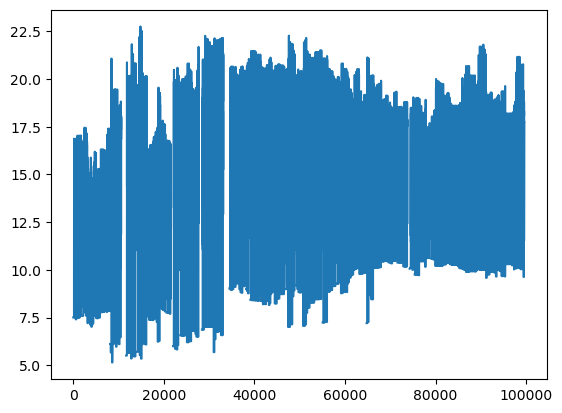

In [25]:
# Simple plot of the matchup SST values
plt.plot(obs_df['sst'])
min(obs_df['sst'])


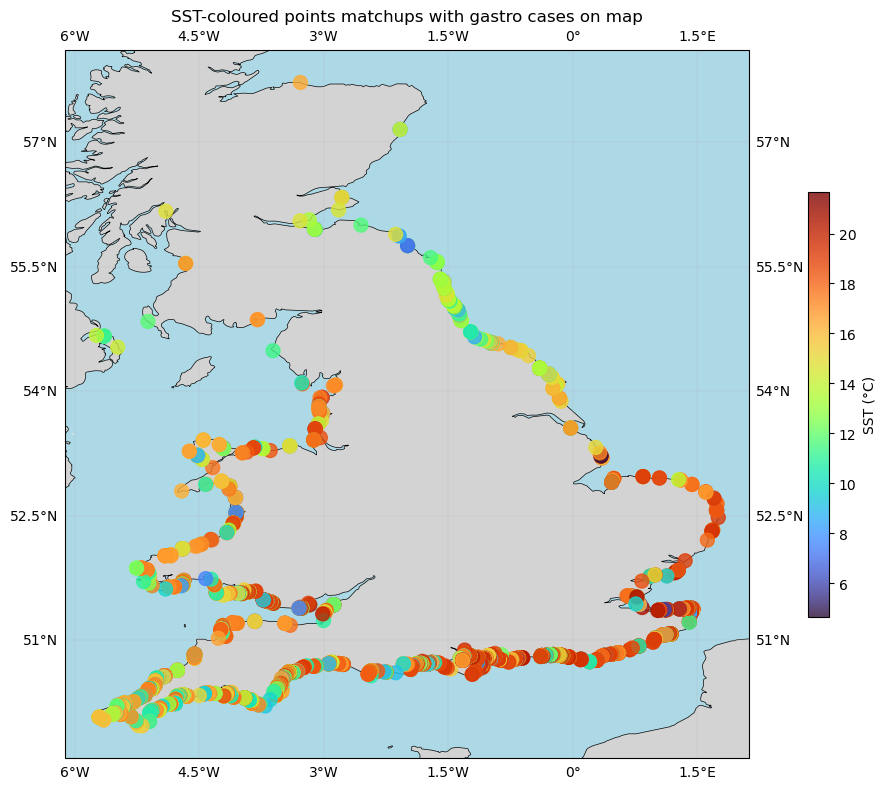

In [ ]:
# Plotting the matchups points on a map, coloured by the SST value
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(obs_df['lon'], obs_df['lat'],
                c=obs_df['sst'],     # colour by this column
                cmap='turbo',        # colormap
                s=100,               # marker size
                alpha=0.8,
                transform=ccrs.PlateCarree(),
                zorder=5)

plt.colorbar(sc, ax=ax, label='SST (°C)', shrink=0.6)
ax.set_title('SST-coloured points matchups with SAS gastro cases on map')
plt.tight_layout()
plt.savefig(os.path.join(plots_root, 'sst_gastro_on_map.png'), dpi=150)
plt.show()

In [ ]:
out_data_name = os.path.join(obs_data_root, 'outputs', 'sas_23feb_test_sst.csv')
obs_df.to_csv(out_data_name)

NameError: name 'os' is not defined

In [ ]:
# Load observed locations from CSV file - EA monitoring data on E coli
obs_data_root = '/data/datasets/Projects/CHANGE/data'
obs_data_name = os.path.join(obs_data_root, 'EA_Ecoli', 'ALL_BW_data_2012-2025.csv')

obs_df = pd.read_csv(obs_data_name)

# Transform UK National Grid easting, northing coordinates to lat, lon
# What is difference between 'ngrx' and 'ngrx (values)' columns?
transformer = Transformer.from_crs("epsg:27700", "epsg:4326", always_xy=True)
lons, lats = transformer.transform(obs_df['ngrx'].values, obs_df['ngry'].values)
obs_df['lat'], obs_df['lon'] = lats, lons

# Remove invalid rows, with missing lat/lon
obs_df = obs_df.dropna(subset=['lon', 'lat'])

# Add time variable, at midday for dates
obs_df['date_time'] = pd.to_datetime(obs_df['sampleTime'])
obs_df

# Store the data with the lat, lon, time columns
out_data_name = os.path.join(obs_data_root, 'EA_Ecoli', 'ALL_BW_data_2012-2025_latlon.csv')
obs_df.to_csv(out_data_name)

In [22]:
# Abritrary threshold of EA E coli data for plotting test
high_ecoli = {'=', '>'}
obs_filtered_df = obs_df[obs_df['escherichiaColiQualifier'].isin(high_ecoli)]
obs_filtered_df

,EUBWID,label,sampleTime,intestinalEnterococciQualifier,intestinalEnterococciCount,escherichiaColiQualifier,escherichiaColiCount,Unnamed: 7,Count (values),ngrx,ngrx (values),ngry,ngry (values),lat,lon,date_time,sst
0,ukc1101-06000,Seaton Carew North,2012-05-10T14:28:00,=,145.0,=,118.0,Coastal,Coastal,452601,452601,530257,530257,54.664669,-1.186040,2012-05-10 14:28:00,7.51001
1,ukc1101-06000,Seaton Carew North,2012-05-15T10:36:00,=,234.0,=,440.0,Coastal,Coastal,452601,452601,530257,530257,54.664669,-1.186040,2012-05-15 10:36:00,7.51001
3,ukc1101-06000,Seaton Carew North,2012-05-31T12:04:00,=,18.0,=,64.0,Coastal,Coastal,452601,452601,530257,530257,54.664669,-1.186040,2012-05-31 12:04:00,7.51001
4,ukc1101-06000,Seaton Carew North,2012-06-11T12:02:00,=,360.0,=,2400.0,Coastal,Coastal,452601,452601,530257,530257,54.664669,-1.186040,2012-06-11 12:02:00,7.51001
6,ukc1101-06000,Seaton Carew North,2012-06-26T12:49:00,<,10.0,=,45.0,Coastal,Coastal,452601,452601,530257,530257,54.664669,-1.186040,2012-06-26 12:49:00,7.51001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99807,ukk4307-33900,Westward Ho!,2024-07-12T12:21:00,<,10.0,=,91.0,Coastal,Coastal,243338,243338,129537,129537,51.043763,-4.236176,2024-07-12 12:21:00,NaN
99809,ukk4307-33900,Westward Ho!,2024-07-22T10:09:00,<,10.0,=,36.0,Coastal,Coastal,243338,243338,129537,129537,51.043763,-4.236176,2024-07-22 10:09:00,NaN
99813,ukk4307-33900,Westward Ho!,2024-08-22T11:22:00,<,10.0,=,18.0,Coastal,Coastal,243338,243338,129537,129537,51.043763,-4.236176,2024-08-22 11:22:00,NaN
99821,ukk4307-33900,Westward Ho!,2025-05-27T10:09:00,<,10.0,=,36.0,Coastal,Coastal,243338,243338,129537,129537,51.043763,-4.236176,2025-05-27 10:09:00,NaN


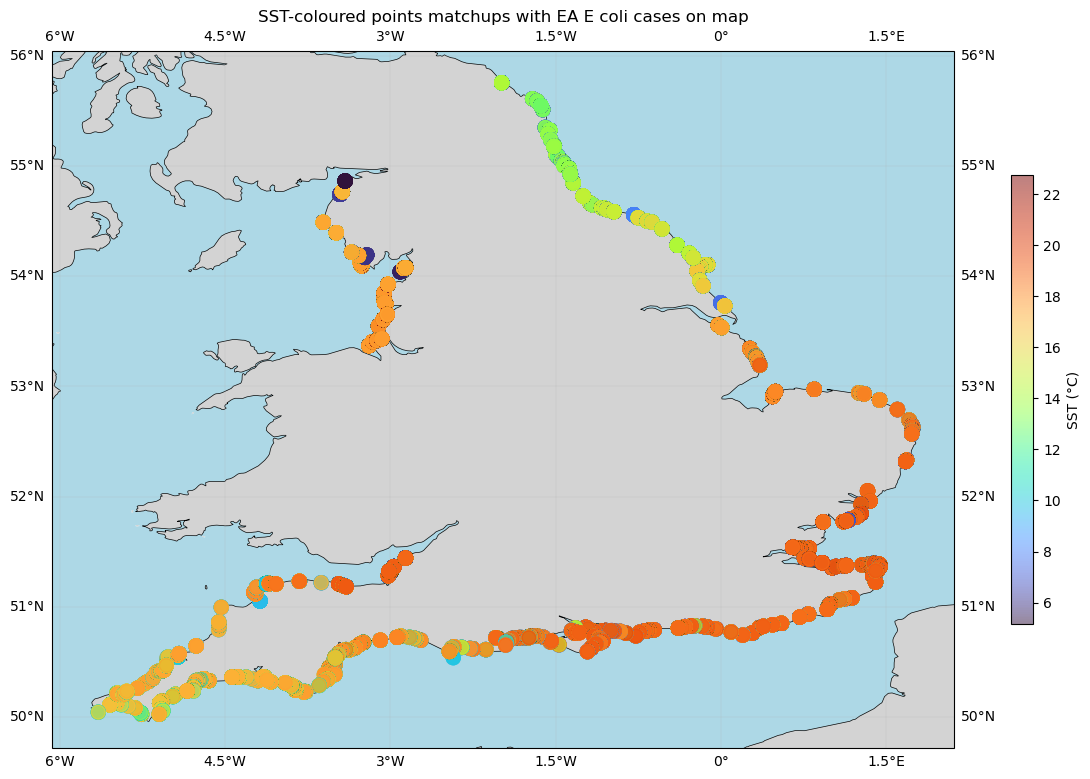

In [23]:
# Plotting the matchups points on a map, coloured by the SST value
fig, ax = plt.subplots(figsize=(12, 8),
                       subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(obs_filtered_df['lon'], obs_filtered_df['lat'],
                c=obs_filtered_df['sst'],     # colour by this column
                cmap='turbo',        # colormap
                s=100,               # marker size
                alpha=0.5,
                transform=ccrs.PlateCarree(),
                zorder=5)

plt.colorbar(sc, ax=ax, label='SST (°C)', shrink=0.6)
ax.set_title('SST-coloured points matchups with EA E coli cases on map')
plt.tight_layout()
plt.savefig(os.path.join(plots_root, 'sst_ecoli_on_map.png'), dpi=150)
plt.show()